In [11]:
from surfx import electrode_potential
import numpy as np
import matplotlib.pyplot as plt
#import cmap
import matplotlib

Linear surface trap
-------------------

Let's start with a very simple five-wire linear surface electrode trap.

We start with a function that returns a parametrized system of surface
electrodes. This way different designs can be compared quickly and the
design parameter space can be explored.

There ware two rf wires running along `x` with width in the `y`
direction of `top` and `bottom`. Between them, there is a long `dc`
electrode `c` of width `mid`. Above and below the rf electrodes there
are three dc electrodes `tl, tm, tr` and `bl, bm, br` to provide stray
field compensation, axial confinement and knobs to change the curvature
tensor.

In [76]:
def five_wire(edge, width, top, mid, bot):
    e, r, t, m, b = edge, width/2, top + mid/2, mid/2, -bot - mid/2
    electrodes = [
        [[(-e, e), (-e, t), (-r, t), (-r, e)]],
        [[(-r, e), (-r, t), (r, t), (r, e)]],
        [[(r, e), (r, t), (e, t), (e, e)]],
        [[(-e, -e), (-r, -e), (-r, b), (-e, b)]],
        [[(-r, -e), (r, -e), (r, b), (-r, b)]],
        [[(r, -e), (e, -e), (e, b), (r, b)]],
        [[(-e, t), (-e, m), (e, m), (e, t)],
               [(-e, b), (e, b), (e, -m), (-e, -m)]],
        [[(-e, m), (-e, -m), (e, -m), (e, m)]],
        ]
    electrodes =[np.array(p) for p in electrodes]
    # s = System([PolygonPixelElectrode(name=n, paths=map(np.array, p))
    #             for n, p in electrodes])
    # s["r"].rf = 1.
    return electrodes

## Some settings

In [ ]:
cover_height = 1000 #height of the mesh
#Notice that for this parameter to take effect, you need to set the cover_nmax parameter in the electrode_potential function to a value greater than 0.

trap_width = 50
center_dc=20
rf_width = 10
rf_separation = 10

electrodes =five_wire(trap_width, center_dc, rf_width, rf_separation, rf_width)

norm = matplotlib.colors.Normalize(vmin=-10.0, vmax=10.0)
cmap = matplotlib.cm.get_cmap('RdBu')

## Electric potential

Text(0, 0.5, 'Potential (V)')

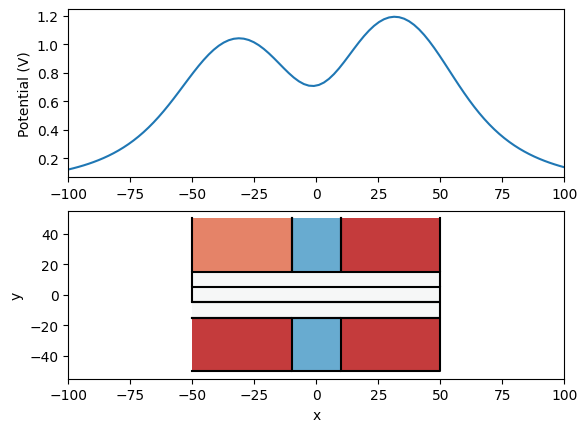

In [175]:
voltages = [5, -5, 7, 7,-5,7,0,0]

fig, axs = plt.subplots(2,1)
xlim = 100
x_positions = np.linspace(-xlim, xlim, 100)

total_potential = np.zeros((100))
for idx, electrode in enumerate(electrodes):
    
    axs[1].fill(*electrode.T, facecolor=cmap(1-norm(voltages[idx])))
    axs[1].plot(*electrode.T, "k-")
    total_potential += electrode_potential(electrode, voltages[idx], x= x_positions, y=0, z=20, derivative=0, cover_height=cover_height)

axs[0].plot(x_positions, total_potential)

for ax in axs:
    ax.set_xlim(-xlim, xlim)

axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[0].set_ylabel("Potential (V)")

## Pseudopotential

(100, 100)


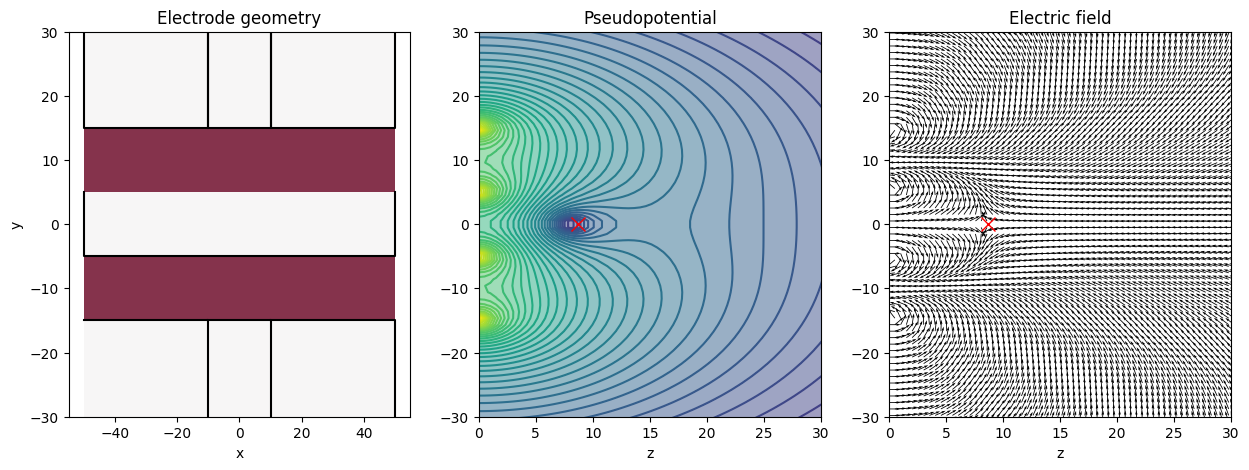

In [168]:

fig, axs = plt.subplots(1,3, figsize=(15,5))
y_lim =50
z_lim = 20

y_positions = np.linspace(-y_lim, y_lim, 100)
z_positions = np.linspace(0, 50, 100)
mesh_y, mesh_z = np.meshgrid(y_positions, z_positions)

rf_voltage = 50

print(mesh_z.shape)

for idx, electrode in enumerate(electrodes):

    if idx == 6: #Choosing RF electrode
        axs[0].fill(*electrode.T, facecolor=cmap(0), alpha=0.8)
        
        
        #Pseudo potential, ion independent.
        axs[1].contourf(mesh_z, mesh_y, np.log(electrode_potential(electrode, rf_voltage, x=30, y=mesh_y, z=mesh_z, derivative=0, cover_height=cover_height, pseudo=True)), levels=50, alpha = 0.5)
        axs[1].contour(mesh_z, mesh_y, np.log(electrode_potential(electrode, rf_voltage, x=30, y=mesh_y, z=mesh_z, derivative=0, cover_height=cover_height, pseudo=True)), levels=50)
        
        # Electric field from the RF
        field = electrode_potential(electrode, rf_voltage, x=0, y=mesh_y, z=mesh_z, derivative=1, cover_height=cover_height)
        field = field / np.sqrt(field[:,:,1]**2 + field[:,:,2]**2)[:,:,None] #normalise the field for better visualization. All arrows should have same length, but different directions.
        axs[2].quiver(mesh_z, mesh_y, field[:,:, 2], field[:,:, 1], scale=30)

    else:
        axs[0].plot(*electrode.T, "k-")
        axs[0].fill(*electrode.T, facecolor=cmap(int(255/2)))



for ax in axs:
    ax.set_ylim(-30, 30)

for ax in axs[1:]:
    ax.set_xlim(0,30)
    ax.set_xlabel("z")
    rf_null = np.sqrt(2*rf_width*rf_separation+rf_separation**2)/2
    #See 10.1103/PhysRevA.78.033402

    ax.plot(rf_null, 0, "x", color="red", label="rf null", ms=10)

axs[0].set_ylabel("y")
axs[0].set_xlabel("x")

for ax, title in zip(axs, ["Electrode geometry", "Pseudopotential", "Electric field"]):
    ax.set_title(title)

# axs[2].set_xlim(0, 20)



Notice a slight discrepancy between the RF null height and the theoretical value calculated from 10.1103/PhysRevA.78.033402 (red cross). This is caused by the finite size of the RF electrode. If you increase the rf electrode lenght, the computed null approaches the theoretical value. 